In [1]:
# dataset: Social_Network_Ads.csv

### import the libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### Read the dataset

In [3]:
df = pd.read_csv('Social_Network_Ads.csv')

In [4]:
df.head(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

#### separate input and output data

In [7]:
x = df[['Age', 'EstimatedSalary']]  # input

y = df['Purchased']   # output

In [8]:
y.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

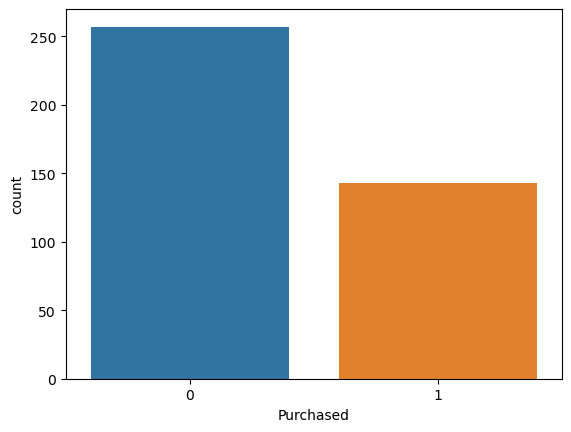

In [9]:
import seaborn as sns

sns.countplot(x = y);

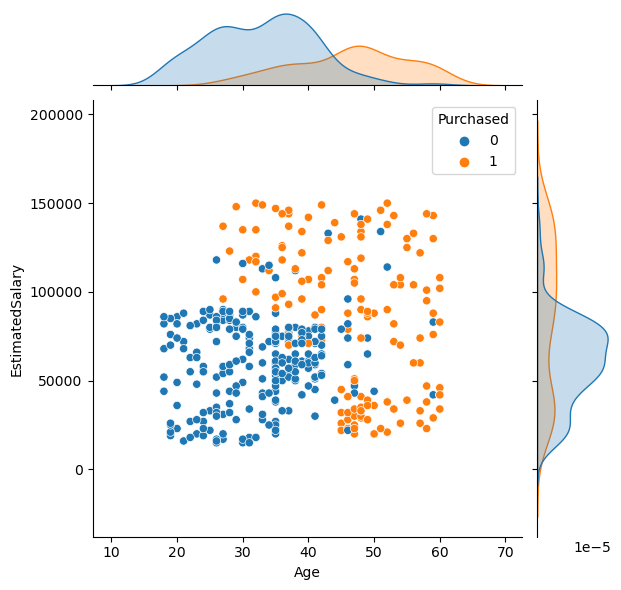

In [10]:
sns.jointplot(x = 'Age', y = 'EstimatedSalary', hue = 'Purchased',
             data = df);

In [11]:
x.describe()

,Age,EstimatedSalary
count,400.000000,400.000000
mean,37.655000,69742.500000
std,10.482877,34096.960282
min,18.000000,15000.000000
25%,29.750000,43000.000000
50%,37.000000,70000.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


### Feature Scaling

In [12]:
from sklearn.preprocessing import MinMaxScaler
sca = MinMaxScaler()
x_scaled = sca.fit_transform(x)

In [13]:
pd.DataFrame(x_scaled).describe()

,0,1
count,400.000000,400.000000
mean,0.467976,0.405500
std,0.249592,0.252570
min,0.000000,0.000000
25%,0.279762,0.207407
50%,0.452381,0.407407
75%,0.666667,0.540741
max,1.000000,1.000000


#### Cross Validation

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y,
                                                   random_state=0,
                                                   test_size= 0.25)

In [16]:
x_train.shape

(300, 2)

In [17]:
y_train.shape

(300,)

### Build the model

In [19]:
# import the class
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [20]:
svc = SVC(kernel = 'rbf', random_state= 0)
dt = DecisionTreeClassifier(random_state=0)
knn = KNeighborsClassifier(n_neighbors= 5)
nb = GaussianNB()
logr = LogisticRegression()

In [21]:
# train the model

svc.fit(x_train,y_train)
dt.fit(x_train,y_train)
knn.fit(x_train,y_train)
nb.fit(x_train,y_train)
logr.fit(x_train,y_train)

LogisticRegression()

#### Prediction on testing data

In [22]:
y_pred_svc = svc.predict(x_test)
y_pred_dt = dt.predict(x_test)
y_pred_knn = knn.predict(x_test)
y_pred_nb = nb.predict(x_test)
y_pred_logr = logr.predict(x_test)

### Evaluation

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

In [25]:
print('SVC',accuracy_score(y_test, y_pred_svc)*100)
print('dt',accuracy_score(y_test, y_pred_dt)*100)
print('knn',accuracy_score(y_test, y_pred_knn)*100)
print('nb',accuracy_score(y_test, y_pred_nb)*100)
print('logr',accuracy_score(y_test, y_pred_logr)*100)

SVC 93.0
dt 90.0
knn 93.0
nb 90.0
logr 89.0


### Voting Classification

In [26]:
from sklearn.ensemble import VotingClassifier

In [33]:
vot = VotingClassifier(estimators=[('logr', logr),
                                  ('dt', dt),
                                  ('knn', knn),
                                  ('svc', svc),
                                  ('nb', nb)])

In [34]:
vot.fit(x_train, y_train)

VotingClassifier(estimators=[('logr', LogisticRegression()),
                             ('dt', DecisionTreeClassifier(random_state=0)),
                             ('knn', KNeighborsClassifier()),
                             ('svc', SVC(random_state=0)),
                             ('nb', GaussianNB())])

In [35]:
y_pred = vot.predict(x_test)

In [36]:
accuracy_score(y_test, y_pred)

0.93